## Imports

In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from collections import Counter

# For Proyecto 3
# from sklearn.model_selection import train_test_split
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.feature_extraction.text import CountVectorizer

## 1. Introducción teórica
• Explique brevemente qué son los mensajes spam y ham.

• Comente por qué es relevante diferenciarlos y cómo se puede aplicar la clasificación automática en este contexto.


### Que es el spam y el ham?
El spam se refiere a mensajes no solicitados, que se envían en grandes cantidades a través de medios electrónicos, como el correo electrónico o los mensajes de texto. Estos mensajes suelen ser molestos y pueden contener publicidad, estafas o contenido malicioso.

El ham, por otro lado, se refiere a mensajes legítimos y deseados que no son spam. Estos mensajes pueden ser correos electrónicos personales, mensajes de texto entre amigos o cualquier comunicación que no sea considerada como spam.

### Relevancia de diferenciar entre spam y ham
Diferenciar entre spam y ham es crucial para mejorar la experiencia del usuario y proteger la seguridad en línea. La clasificación automática de mensajes permite filtrar el spam de manera eficiente, evitando que los usuarios reciban mensajes no deseados y reduciendo el riesgo de caer en estafas o malware.

## 2. Carga y exploración de los datos (EDA) Realice un análisis exploratorio inicial del dataset:
• Cargue el dataset en Python.

• Muestre 5 mensajes aleatorios.

• Genere las siguientes visualizaciones:

    o Cantidad total de mensajes.
    o Distribución y proporción de mensajes spam vs ham.
    o Gráfica de densidad de la longitud de los mensajes spam.
    o Gráfica de densidad de la longitud de los mensajes ham.
    o Top 20 palabras más frecuentes en mensajes spam.
    o Top 20 palabras más frecuentes en mensajes ham.
    o Visualización de palabras clave usando WordCloud para cada clase.


In [45]:
# open the csv file and read it into a pandas dataframe
df = pd.read_csv("Data/SpamHam.csv", encoding="latin-1", sep=";")

print("Number of rows in the dataframe:", len(df))

# Show 5 random rows of the dataframe
random.seed(1234)
df_sample = df.sample(n=5)
df_sample

Number of rows in the dataframe: 5564


,Label,SMS_TEXT
3734,ham,Hows the street where the end of library walk is?
3180,ham,"My Parents, My Kidz, My Friends n My Colleague..."
3131,ham,So no messages. Had food?
1517,ham,Check wid corect speling i.e. Sarcasm
3032,ham,Get ready for &lt


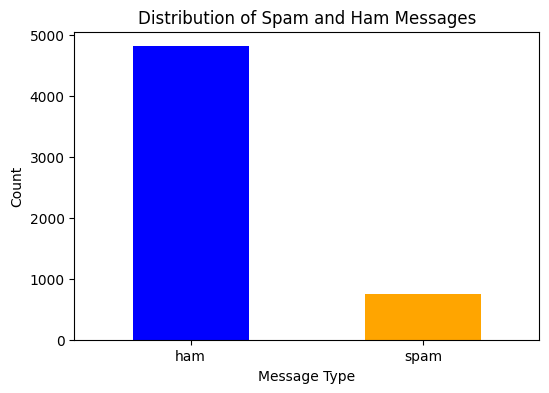

In [46]:
# Show the number of spam and ham messages in the dataset
plt.figure(figsize=(6, 4))
df["Label"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

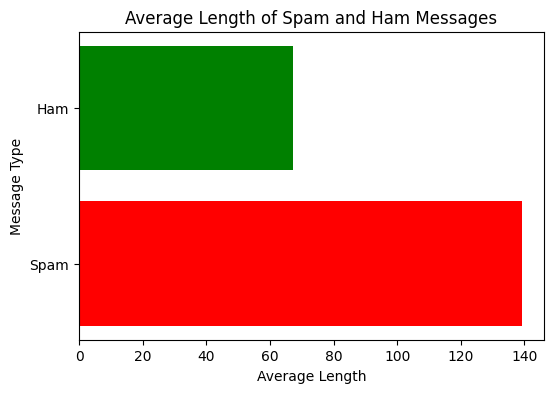

In [47]:
# Length of the avg spam and ham messages
plt.figure(figsize=(6, 4))
df["Message_Length"] = df["SMS_TEXT"].fillna("").astype(str).apply(len)
avg_length_spam = df[df["Label"] == "spam"]["Message_Length"].mean()
avg_length_ham = df[df["Label"] == "ham"]["Message_Length"].mean()

plt.barh(["Spam", "Ham"], [avg_length_spam, avg_length_ham], color=["red", "green"])
plt.title("Average Length of Spam and Ham Messages")
plt.xlabel("Average Length")
plt.ylabel("Message Type")
plt.show()

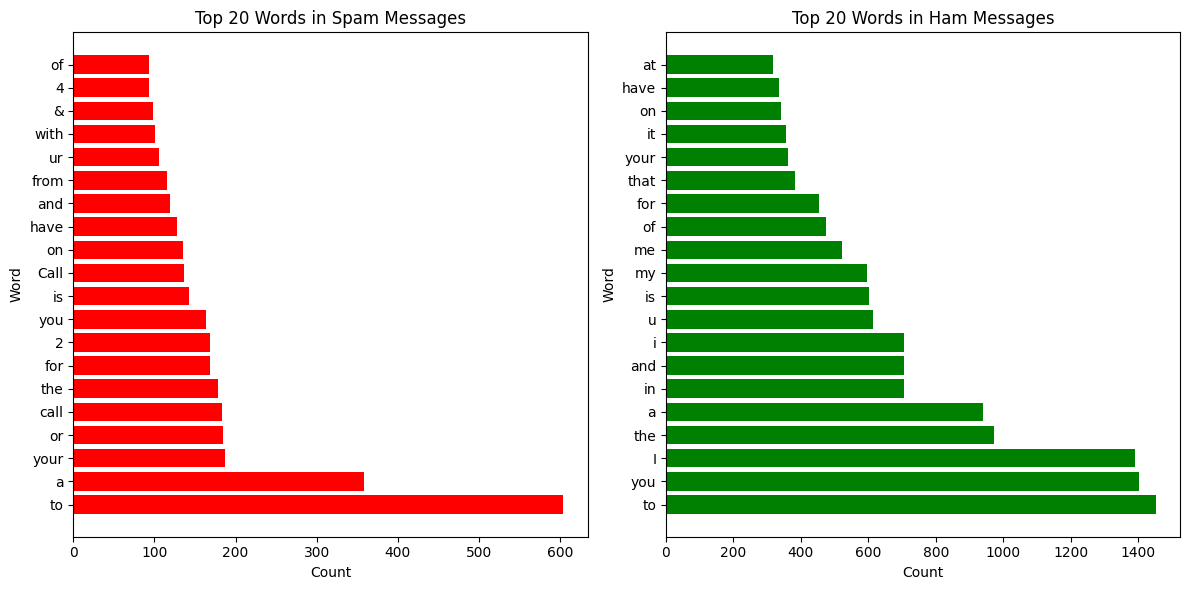

In [48]:
# Top 20 most common words in spam and ham messages
def get_top_words(messages, n=20):
    all_words = " ".join(messages).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)
top_spam_words = get_top_words(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
top_ham_words = get_top_words(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh([word for word, count in top_spam_words], [count for word, count in top_spam_words], color="red")
plt.title("Top 20 Words in Spam Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.subplot(1, 2, 2)
plt.barh([word for word, count in top_ham_words], [count for word, count in top_ham_words], color="green")
plt.title("Top 20 Words in Ham Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

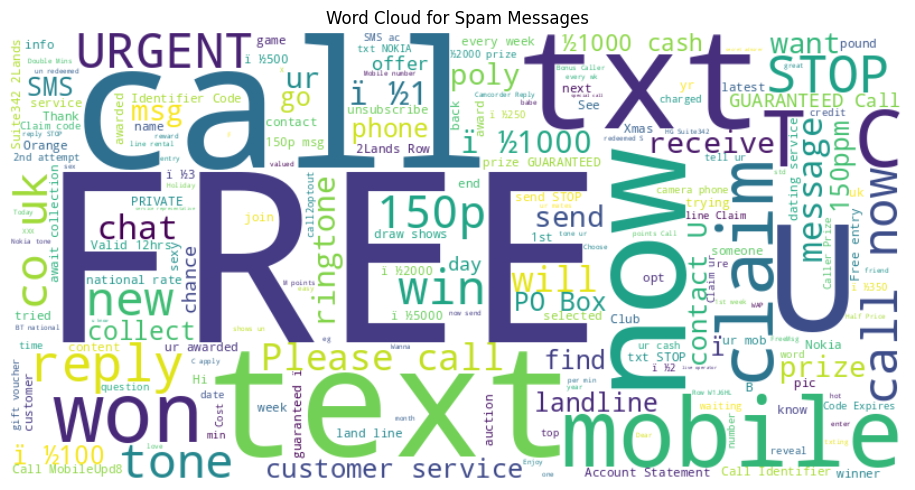

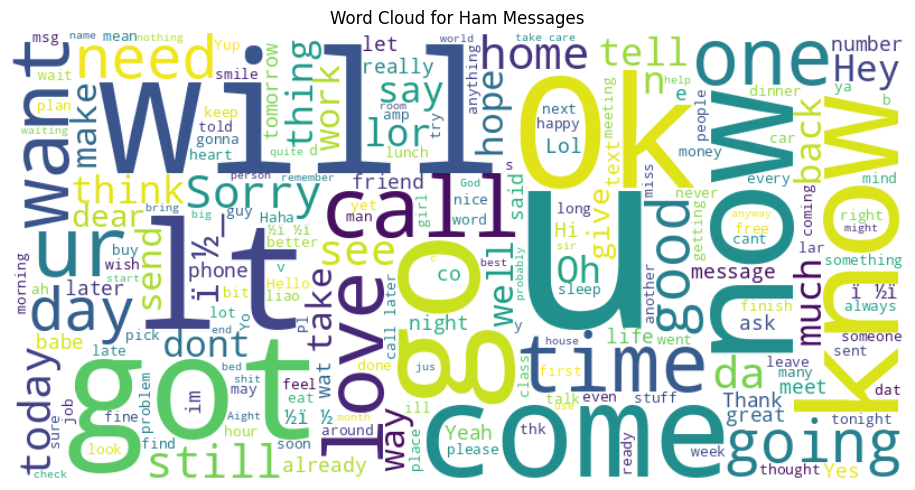

In [49]:
# Show keywords of spam and ham using word clouds
from wordcloud import WordCloud
spam_text = " ".join(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
ham_text = " ".join(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))
spam_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(spam_text)
ham_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ham_text)

plt.figure(figsize=(12, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Spam Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Ham Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de texto
Utilizando el modulo de python NLTK, aplique las siguientes transformaciones al texto, explicando qué hace cada una y por qué es útil:

**Tokenización:** Divide cada mensaje en una lista de palabras (tokens) individuales. Es el primer paso necesario para procesar el texto de forma granular.

**Conversión a minúsculas:** Normaliza el texto para que "FREE" y "free" sean tratadas como la misma palabra, reduciendo la dimensionalidad del vocabulario.

**Eliminación de signos de puntuación:** Remueve caracteres no alfanuméricos (`.`, `!`, `?`, etc.) que no aportan información semántica útil para la clasificación.

**Eliminación de stopwords:** Elimina palabras muy frecuentes del idioma ("the", "is", "and", etc.) que aparecen por igual en spam y ham y no ayudan a diferenciar entre clases.

**Stemming (PorterStemmer):** Reduce cada palabra a su raíz morfológica (e.g., "running" → "run", "winner" → "winner"). Se eligió stemming sobre lemmatización porque es más rápido, no requiere corpus adicional (como WordNet), y para clasificación de spam la raíz aproximada es suficiente para capturar el significado relevante.

In [50]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Tokenization
df["SMS_TEXT"] = df["SMS_TEXT"].fillna("").astype(str).apply(word_tokenize)

# Lowercase
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [word.lower() for word in x])

# Remove punctuation
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [word for word in x if word.isalnum()])

# Remove stopwords
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [word for word in x if word not in stop_words])

# Stemming
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [stemmer.stem(word) for word in x])

# Join tokens back into a string for later vectorization
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: ' '.join(x))

## 4. Análisis posterior al preprocesamiento
Una vez preprocesado el texto, vuelva a realizar los análisis del punto 2 con el dataset
transformado:

• Cantidad total de mensajes.

• Proporción de spam vs ham.

• Gráficas de densidad de longitud (spam y ham).

• Top 20 palabras más frecuentes en cada clase.

• WordCloud para cada clase.

In [51]:
# Show length of the cleaned dataframe
print("Number of rows in the cleaned dataframe:", len(df))

# Show 5 random rows of the cleaned dataframe
random.seed(1234)
df_sample_cleaned = df.sample(n=5)
df_sample_cleaned


Number of rows in the cleaned dataframe: 5564


,Label,SMS_TEXT,Message_Length
5053,ham,havent stuck orchard dad car go 4 dinner u leh...,91
2886,ham,take phone callon friday assum wo year,95
1158,ham,sure neighbor didnt pick,40
4054,ham,ha ha nan yalrigu heltini iyo kothi chikku u s...,249
3143,ham,get tomorrow send,42


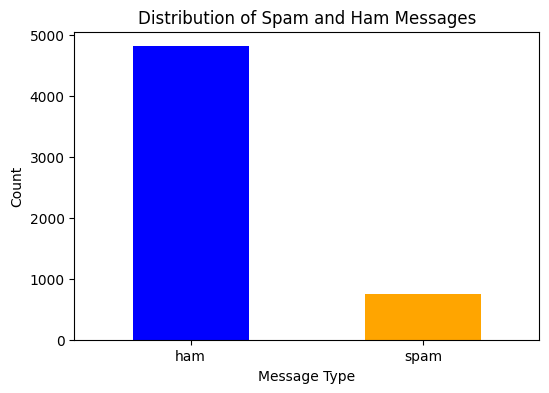

In [52]:
# Show the number of spam and ham messages in the dataset
plt.figure(figsize=(6, 4))
df["Label"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

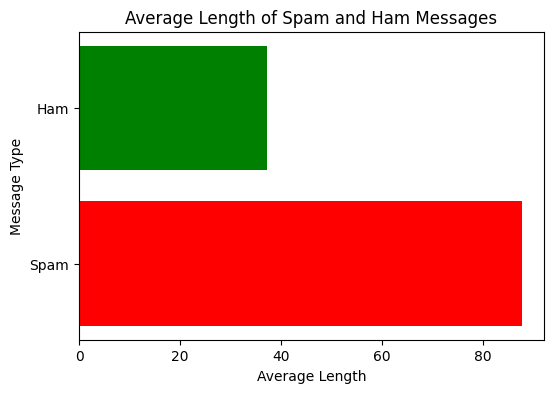

In [53]:
# Length of the avg spam and ham messages
plt.figure(figsize=(6, 4))
df["Message_Length"] = df["SMS_TEXT"].fillna("").astype(str).apply(len)
avg_length_spam = df[df["Label"] == "spam"]["Message_Length"].mean()
avg_length_ham = df[df["Label"] == "ham"]["Message_Length"].mean()

plt.barh(["Spam", "Ham"], [avg_length_spam, avg_length_ham], color=["red", "green"])
plt.title("Average Length of Spam and Ham Messages")
plt.xlabel("Average Length")
plt.ylabel("Message Type")
plt.show()

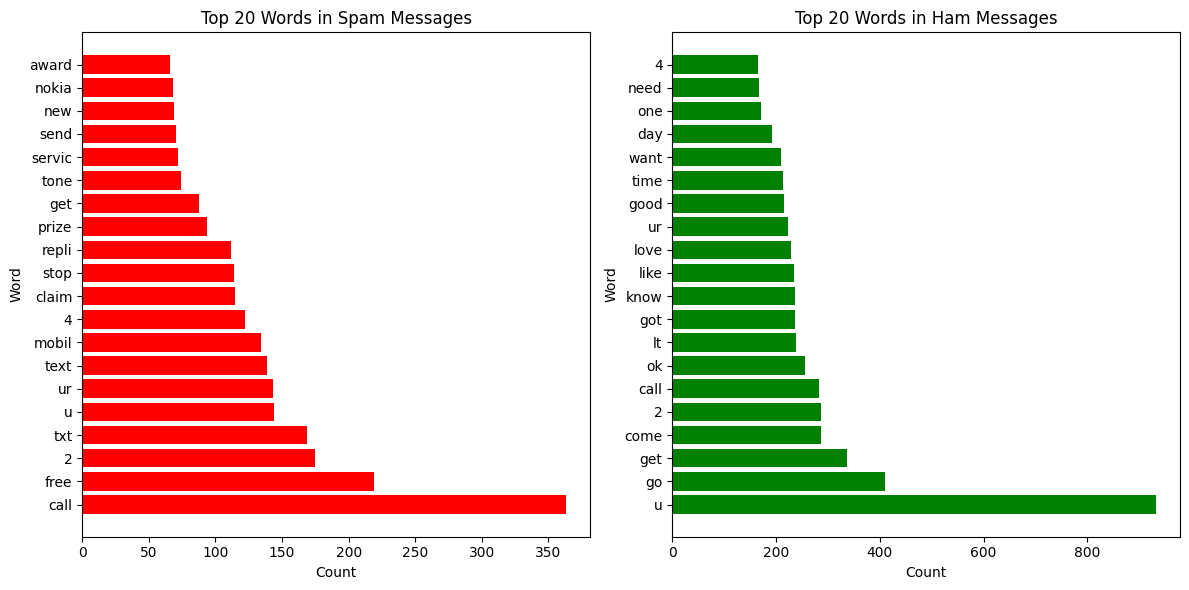

In [54]:
# Top 20 most common words in spam and ham messages
def get_top_words(messages, n=20):
    all_words = " ".join(messages).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)
top_spam_words = get_top_words(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
top_ham_words = get_top_words(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh([word for word, count in top_spam_words], [count for word, count in top_spam_words], color="red")
plt.title("Top 20 Words in Spam Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.subplot(1, 2, 2)
plt.barh([word for word, count in top_ham_words], [count for word, count in top_ham_words], color="green")
plt.title("Top 20 Words in Ham Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

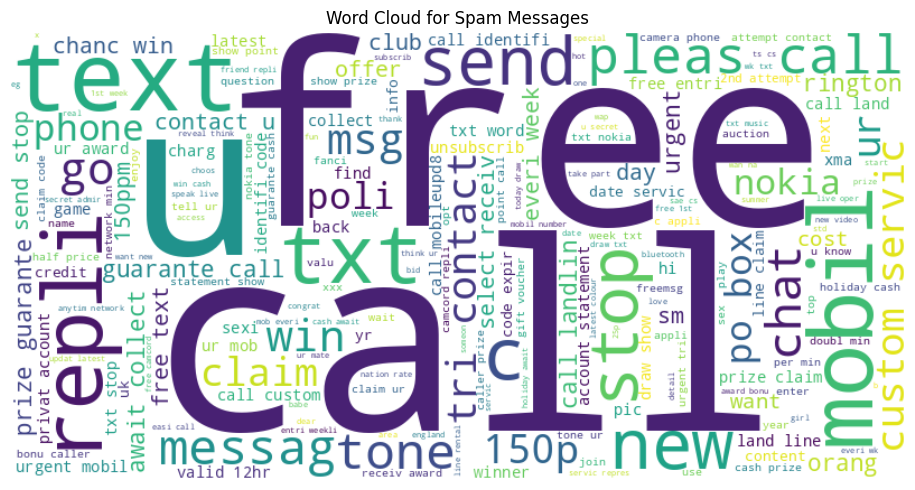

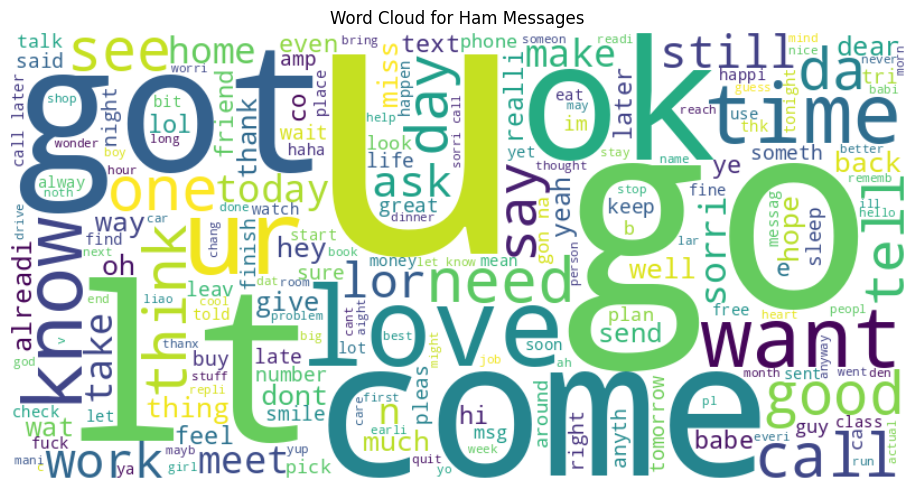

In [55]:
# Show keywords of spam and ham using word clouds
from wordcloud import WordCloud
spam_text = " ".join(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
ham_text = " ".join(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))
spam_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(spam_text)
ham_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ham_text)

plt.figure(figsize=(12, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Spam Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Ham Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Reflexión y análisis
Responda las siguientes preguntas:

• ¿Qué cambios son más notorios entre los indicadores antes y después del
preprocesamiento?

• Respecto a las 20 palabras más frecuentes en ambos grupos:

    o ¿Hay palabras en común entre spam y ham?
    o ¿Qué palabras son exclusivas de cada clase?
    o ¿Qué información o patrones puede deducir de estas diferencias?

• Según su análisis exploratorio, ¿qué características del texto podrían ser útiles para
distinguir entre un mensaje spam y uno ham?

### ¿Qué cambios son más notorios entre los indicadores antes y después del
preprocesamiento?
Principalmente entre las palabras más frecuentes, ya que el preprocesamiento elimina palabras comunes (stopwords) y reduce las palabras a su raíz (stemming), estas son las que siempre aparecen en ambos grupos y son muy frecuentes, por lo que no aportan información relevante para diferenciar entre spam y ham. 
Además, el preprocesamiento puede revelar palabras clave que son más representativas de cada clase, lo que puede ayudar a identificar patrones específicos en los mensajes spam y ham.

### Respecto a las 20 palabras más frecuentes en ambos grupos:
#### ¿Hay palabras en común entre spam y ham?

Entre las palabras mas frecuentes en ambos grupos, es común encontrar palabras como 'ur', 'get', 'u', '2', 'call' y '4'.

In [56]:
# Common words between spam and ham
common_words = set(word for word, count in top_spam_words) & set(word for word, count in top_ham_words)
print("Common words between spam and ham:", common_words)

Common words between spam and ham: {'ur', 'get', 'u', '2', 'call', '4'}


#### ¿Qué palabras son exclusivas de cada clase?

In [57]:
# Top words exclusive to spam and ham
exclusive_spam_words = set(word for word, count in top_spam_words) - set(word for word, count in top_ham_words)
exclusive_ham_words = set(word for word, count in top_ham_words) - set(word for word, count in top_spam_words)
print("Exclusive words in spam messages:", exclusive_spam_words)
print("Exclusive words in ham messages:", exclusive_ham_words)

Exclusive words in spam messages: {'send', 'text', 'repli', 'mobil', 'nokia', 'txt', 'award', 'free', 'tone', 'claim', 'prize', 'servic', 'stop', 'new'}
Exclusive words in ham messages: {'day', 'good', 'go', 'love', 'time', 'like', 'know', 'need', 'come', 'got', 'want', 'one', 'ok', 'lt'}


#### ¿Qué información o patrones puede deducir de estas diferencias?
Las palabras exclusivas de cada clase pueden indicar temas o características específicas asociadas con el spam o el ham. Por ejemplo, las palabras exclusivas del spam podrían incluir términos relacionados con ofertas, promociones, o lenguaje persuasivo, mientras que las palabras exclusivas del ham podrían estar relacionadas con conversaciones cotidianas, saludos, o temas personales. Estas diferencias pueden ayudar a identificar patrones de lenguaje que son más comunes en los mensajes spam en comparación con los mensajes ham.

### Según su análisis exploratorio, ¿qué características del texto podrían ser útiles para
distinguir entre un mensaje spam y uno ham?
Las palabras como Free, Call, Ur, Get, 2, 4, etc., que son más frecuentes en los mensajes spam, podrían ser características útiles para distinguir entre un mensaje spam y uno ham. Además, la longitud del mensaje y la presencia de ciertos patrones de lenguaje o palabras clave también podrían ser indicadores importantes para la clasificación automática de mensajes.